# Analyse du marché de l'emploi dans la Data Analyse

## Introduction

Le métier de Data Analyst connaît une forte croissance dans un monde de plus en plus orienté vers les données. Cette analyse s’appuie sur un jeu de données regroupant plusieurs centaines d’offres d’emploi publiées récemment dans le domaine de la data analyse. 
L’objectif est de mieux comprendre les dynamiques du marché de l’emploi pour ce métier : localisation des opportunités, niveaux de salaire, compétences recherchées, etc

Ce projet a une double finalité :
- **Technique** : démontrer les compétences acquises en nettoyage, exploration et visualisation de données.
- **Stratégique** : mettre en évidence la pertinence d'une reconversion dans le domaine de la data, tant en termes d’employabilité que de perspectives de carrière.


source du dataset: « Data Analyst Jobs » sur Kaggle

## Sommaire

1. [Importation des bibliothèques et chargement des données](#1-importation-des-bibliothèques-et-chargement-des-données)  
2. [Nettoyage et préparation du jeu de données](#2-nettoyage-et-préparation-du-jeu-de-données)  
3. [Analyse descriptive](#3-analyse-descriptive)  
4. [Visualisation des données](#4-visualisation-des-données)  
5. [Interprétations et insights métiers](#5-interprétations-et-insights-métiers)  
6. [Conclusion sur le marché de la data analyse](#6-conclusion-sur-le-marché-de-la-data-analyse)

## 1. Importation des bibliothèques et chargement des données

Dans cette première étape, je vais importer les bibliothèques nécessaires à l’analyse (`pandas`, `numpy`, `matplotlib`, `seaborn`, etc.) et charger le dataset.

In [2]:
# import des librairies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st

In [3]:
# import et affichage dataset
data = pd.read_csv('DataAnalyst.csv')
data

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
2250,2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1


## 2. Nettoyage et préparation du jeu de données

Le jeu de données brut peut contenir des informations incomplètes ou mal formatées. dans cette partie je vais :
- Identifier les colonnes importantes pour l’analyse
- Gérer les valeurs manquantes
- Nettoyer les formats (ex. : salaires, localisations)
- Créer des colonnes utiles (ex. : min/max salaire)

Objectif : rendre le jeu de données exploitable pour une analyse fiable.

In [4]:
# controle type de variables
data.dtypes

Unnamed: 0             int64
Job Title             object
Salary Estimate       object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                  object
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
Easy Apply            object
dtype: object

In [5]:
# Filtrage des lignes avec estimation de salaire
dataSal = data[data['Salary Estimate'].str.contains(r'\$|K', na=False)].copy()

# Nettoyage de la colonne 'Salary Estimate'
dataSal.loc[:, 'salaryEstimateClean'] = dataSal['Salary Estimate'].str.replace(r'[^0-9\-]', '', regex=True)

# Séparation en salaire minimum et maximum
dataSal[['minSalary', 'maxSalary']] = dataSal['salaryEstimateClean'].str.split('-', expand=True).astype(float)

# Calcul du salaire moyen
dataSal.loc[:, 'avgSalary'] = dataSal[['minSalary', 'maxSalary']].mean(axis=1)

# Salaire moyen global
globalMeanSalary = dataSal['avgSalary'].mean()
print(f"Salaire moyen global : {globalMeanSalary:.2f} USD/an")

# Calcul du salaire médian
dataSal.loc[:, 'medianSalary'] = dataSal[['minSalary', 'maxSalary']].median(axis=1)

# Salaire médian global 
globalMedianSalary = dataSal['medianSalary'].median()
print(f"Salaire médian global : {globalMedianSalary:.2f} USD/an")

# Aperçu des résultats
dataSal[['Salary Estimate', 'minSalary', 'maxSalary', 'avgSalary', 'medianSalary']].head()


Salaire moyen global : 72.12 USD/an
Salaire médian global : 69.00 USD/an


,Salary Estimate,minSalary,maxSalary,avgSalary,medianSalary
0,$37K-$66K (Glassdoor est.),37.0,66.0,51.5,51.5
1,$37K-$66K (Glassdoor est.),37.0,66.0,51.5,51.5
2,$37K-$66K (Glassdoor est.),37.0,66.0,51.5,51.5
3,$37K-$66K (Glassdoor est.),37.0,66.0,51.5,51.5
4,$37K-$66K (Glassdoor est.),37.0,66.0,51.5,51.5


In [6]:
# repèrer valeur manquante dans Salary Estimate
print(data['Salary Estimate'].isnull().sum())

0


In [7]:
# commme très peu de valeurs sont manquantes: amputation des lignes correspondantes
dataSal = dataSal.dropna(subset=['Salary Estimate'])
data = dataSal.copy()

In [8]:
# Regroupement par ville : moyenne et médiane
salaryByCity = dataSal.groupby('Location').agg({
    'avgSalary': 'mean',
    'medianSalary': 'median',
    'Salary Estimate': 'count'  # pour voir le nombre d'offres par ville
}).rename(columns={'Salary Estimate': 'offerCount'}).sort_values('offerCount', ascending=False)

# Affichage 
salaryByCity

,avgSalary,medianSalary,offerCount
Location,,,
"New York, NY",71.235484,69.0,310
"Chicago, IL",78.726923,77.5,130
"San Francisco, CA",99.273109,92.5,119
"Austin, TX",58.703704,59.0,81
"Los Angeles, CA",67.631250,79.0,80
...,...,...,...
"Henderson, CO",62.000000,62.0,1
"Harrison, NY",72.000000,72.0,1
"Hanford, CA",64.000000,64.0,1


## 3. Analyse descriptive

Dans cette partie je vais essayer de dégager les grandes tendances du dataset :
- Nombre total d'offres d'emploi
- Répartition des offres par ville
- Statistiques de base sur les salaires
- Fréquence des intitulés de poste

Cela permettra d’avoir une première idée du marché de l’emploi pour les data analysts.

In [9]:
# Nombre total d’offres 
totalOffers = len(data)
print(f"Nombre total d'offres avec estimation de salaire : {totalOffers}")

Nombre total d'offres avec estimation de salaire : 2252


### Commentaire sur le volume d’offres :

Le dataset contient 2252 offres d’emploi, ce qui illustre clairement une demande significative de profils en Data Analyse. Ce volume important suggère que le secteur est dynamique et en recherche active de main d’œuvre qualifiée.

Cependant, pour affiner cette observation, il serait pertinent de croiser ces données avec celles d’autres secteurs ou métiers. Cela permettrait d’avoir une vision comparative plus complète et de mieux comprendre si cette demande est une tendance globale ou spécifique au domaine de la data.

In [10]:
# Statistiques globales sur les salaires
globalMeanSalary = data['avgSalary'].mean()
globalMedianSalary = data['medianSalary'].median()

print(f"Salaire moyen global : {globalMeanSalary:.2f} USD/an")
print(f"Salaire médian global : {globalMedianSalary:.2f} USD/an")

Salaire moyen global : 72.12 USD/an
Salaire médian global : 69.00 USD/an


### Commentaire sur les niveaux de salaires observés :

L’analyse des salaires montre une rémunération moyenne estimée à 72 120 USD/an et une médiane à 69 000 USD/an. L’écart relativement faible entre ces deux valeurs suggère une distribution salariale globalement équilibrée, sans présence massive de valeurs extrêmes.

Cela confirme que le métier de Data Analyst est valorisé de manière assez homogène sur le marché, avec des salaires attractifs dès l’entrée dans le métier dans plusieurs régions du monde. Toutefois, il convient de garder à l’esprit que ces estimations ne tiennent pas compte du niveau d’expérience ni du type d’entreprise, qui peuvent fortement influencer les rémunérations.

In [11]:
# Répartition des offres par ville (top 5)
topCities = data['Location'].value_counts().head(5)
print("Top 5 des villes avec le plus d'offres :")
print(topCities)

Top 5 des villes avec le plus d'offres :
Location
New York, NY         310
Chicago, IL          130
San Francisco, CA    119
Austin, TX            81
Los Angeles, CA       80
Name: count, dtype: int64


### Commentaire sur la répartition géographique des offres :

La majorité des offres d’emploi se concentre dans quelques grandes métropoles, avec en tête New York (310 offres), suivie par Chicago (130) et San Francisco (119). Ces villes, toutes situées aux États-Unis, sont connues pour leur dynamisme économique et leur forte implantation de secteurs liés à la finance, à la tech ou à la data.

On retrouve également Austin (81), ville émergente dans le domaine technologique, et Los Angeles (80), qui montre que la demande ne se limite pas aux hubs traditionnels comme la Silicon Valley.

Cette concentration géographique des offres reflète les pôles majeurs d’innovation et de data science, mais souligne aussi un déséquilibre potentiel : les opportunités peuvent être nombreuses, mais inégalement réparties selon les territoires. Cela peut constituer un facteur à considérer dans une perspective de mobilité professionnelle.

In [12]:
# Fréquence des intitulés de poste (top 5)
topTitles = data['Job Title'].value_counts().head(5)
print("Top 5 des intitulés de poste les plus fréquents :")
print(topTitles)

Top 5 des intitulés de poste les plus fréquents :
Job Title
Data Analyst             405
Senior Data Analyst       90
Junior Data Analyst       30
Business Data Analyst     28
Sr. Data Analyst          21
Name: count, dtype: int64


### Commentaire sur les intitulés de poste les plus fréquents :

L’intitulé « Data Analyst » est de loin le plus représenté avec 405 occurrences. 
Les déclinaisons par niveau d’expérience — Senior, Junior, et Business Data Analyst — indiquent que le métier se décline sur différents niveaux hiérarchiques et spécialités.
Cepandant ces observations ne permettent pas à elles seules de faire de conclusion sur le niveau d'experience recherché par les entreprises.

## 4. Visualisation des données

L’objectif de cette partie est de rendre l’analyse plus lisible et impactante grace à des graphique.

### Représentation des salaires moyens (histogramme)

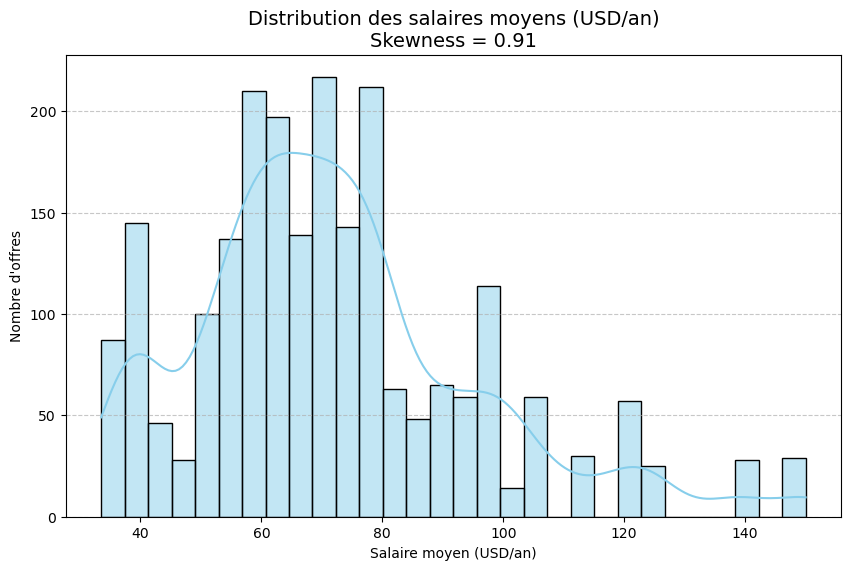

In [16]:
from scipy.stats import skew

# Calcul du skewness sur la colonne des salaires moyens
salarySkewness = skew(data['avgSalary'].dropna())

plt.figure(figsize=(10, 6))
sns.histplot(data['avgSalary'], bins=30, kde=True, color='skyblue')
plt.title(f"Distribution des salaires moyens (USD/an)\nSkewness = {salarySkewness:.2f}", fontsize=14)
plt.xlabel('Salaire moyen (USD/an)')
plt.ylabel('Nombre d\'offres')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Le graphique montre la répartition des salaires moyens dans les offres d’emploi. On observe une forme légèrement étirée vers la droite, ce qui est confirmé par un coefficient d’asymétrie (skewness) de 0.91.

Cela signifie que la majorité des salaires se situent dans une zone relativement concentrée, mais qu’il existe aussi quelques offres avec des salaires beaucoup plus élevés, qui tirent la moyenne vers le haut.

### Comparaison salaire moyens par villes (extrèmes)

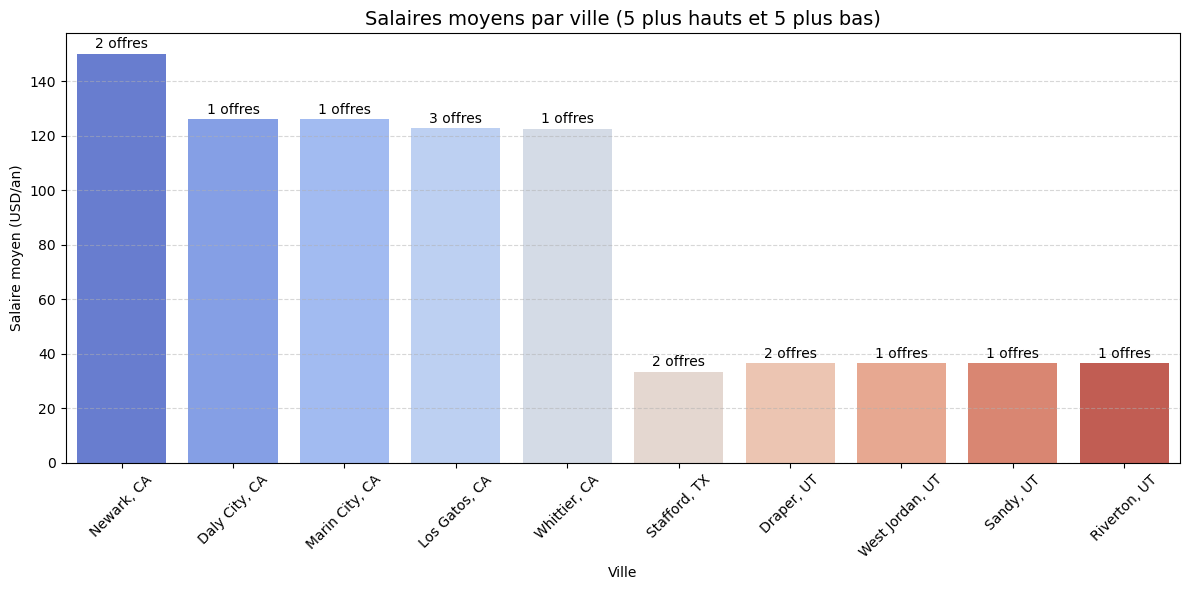

In [17]:
# Création d'un DataFrame avec les extrêmes
top5Cities = salaryByCity.sort_values('avgSalary', ascending=False).head(5)
bottom5Cities = salaryByCity.sort_values('avgSalary', ascending=True).head(5)
extremeCities = pd.concat([top5Cities, bottom5Cities]).reset_index()

# Barplot
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    data=extremeCities, 
    x='Location', 
    y='avgSalary', 
    hue='Location',       # suppression du warning
    dodge=False, 
    palette='coolwarm',
    legend=False          # pas besoin de légende ici
)

# Ajouter les étiquettes (nombre d'offres)
for i, row in extremeCities.iterrows():
    barplot.text(
        x=i, 
        y=row['avgSalary'] + 1,  # petit espace au-dessus de la barre
        s=f"{int(row['offerCount'])} offres", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Habillage du graphique
plt.title("Salaires moyens par ville (5 plus hauts et 5 plus bas)", fontsize=14)
plt.ylabel("Salaire moyen (USD/an)")
plt.xlabel("Ville")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Ce graphique compare les 5 villes où les salaires moyens sont les plus élevés et les 5 villes où ils sont les plus faibles. On observe un écart très marqué entre les extrêmes : certaines villes offrent plus du triple du salaire proposé dans d'autres.

Cela peut refléter des réalités locales du marché, comme le coût de la vie ou la présence de grandes entreprises tech. Toutefois, il est important de relativiser cette observation : le nombre d'offres dans ces villes étant très faible ( 1 ou 2 pour la majorité) donc très peu représentatif de l'ensemble de l'échatillon ( + de 2000 valeurs ).

Ainsi, ces données donnent une tendance intéressante sur les différences de salaires selon les états:
- Le top 5 des villes avec les salaires les plus élevé sont en Californie.
- 4 villes sur 5 comptant les plus bas salaire sont situées dans l'Utah.

Cependant elles ne permettent pas à elles seules de tirer des conclusions solides sur la rémunération selon la localisation.

### top 5 des villes avec le plus d'offres

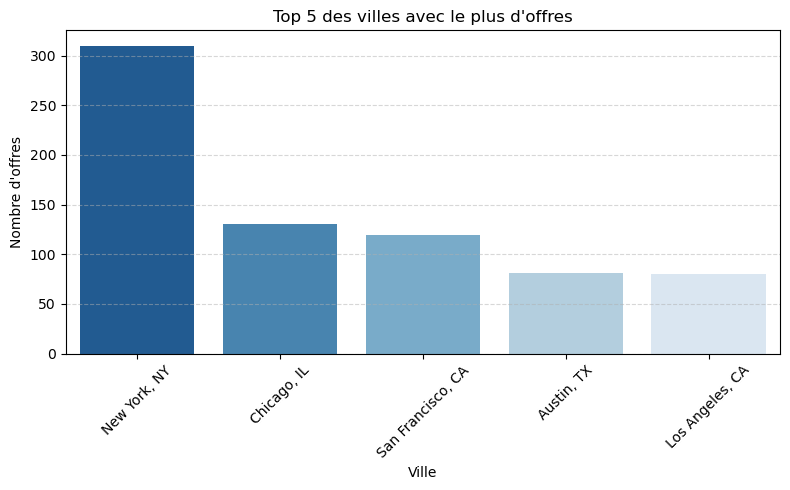

In [58]:
# Création d'un DataFrame à partir des top villes
topCitiesDf = topCities.reset_index()
topCitiesDf.columns = ['Location', 'offerCount']

plt.figure(figsize=(8, 5))
sns.barplot(
    data=topCitiesDf,
    x='Location', 
    y='offerCount',
    hue='Location',         # suppression du warning
    palette='Blues_r',
    legend=False
)

# Habillage
plt.title('Top 5 des villes avec le plus d\'offres')
plt.xlabel('Ville')
plt.ylabel('Nombre d\'offres')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Le graphique montre que certaines villes concentrent une part importante des offres d’emploi en data analyse. New York arrive largement en tête, suivie par Chicago, San Francisco, Austin et Los Angeles. Ces cinq villes regroupent à elles seules une proportion significative des opportunités disponibles.

Cette concentration géographique reflète les dynamiques économiques des États-Unis, où de grandes métropoles — souvent à forte dominante technologique ou financière — attirent et génèrent un grand nombre de postes dans le domaine de la data.

Cela souligne aussi un enjeu d’inégalité territoriale : les opportunités dans ce secteur semblent davantage localisées dans certains pôles urbains majeurs, ce qui peut être un élément à prendre en compte dans une stratégie de mobilité ou de carrière à l’international.

### Observation des intitulés de poste les plus répendus

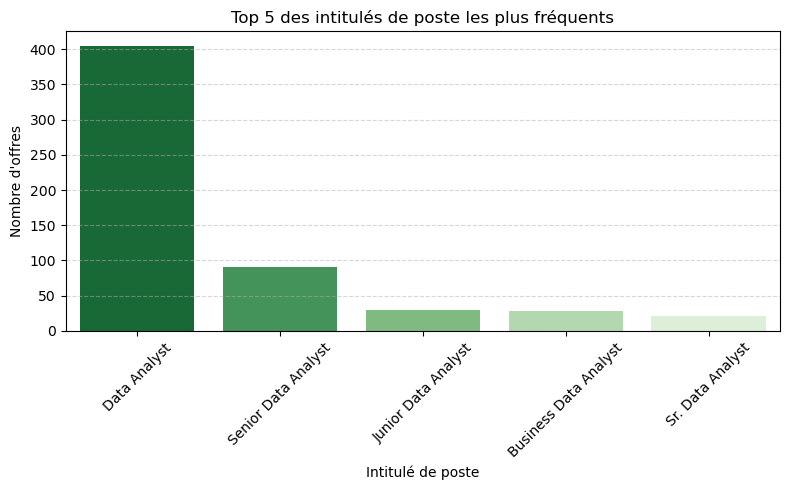

In [19]:
# Préparation des données
topTitles = data['Job Title'].value_counts().head(5)
topTitlesDf = topTitles.reset_index()
topTitlesDf.columns = ['Job Title', 'count']

# Barplot sans warning
plt.figure(figsize=(8, 5))
sns.barplot(
    data=topTitlesDf,
    x='Job Title',
    y='count',
    hue='Job Title',          # pour éviter le warning
    palette='Greens_r',
    legend=False              # on supprime la légende inutile
)

# Habillage
plt.title('Top 5 des intitulés de poste les plus fréquents')
plt.xlabel('Intitulé de poste')
plt.ylabel('Nombre d\'offres')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

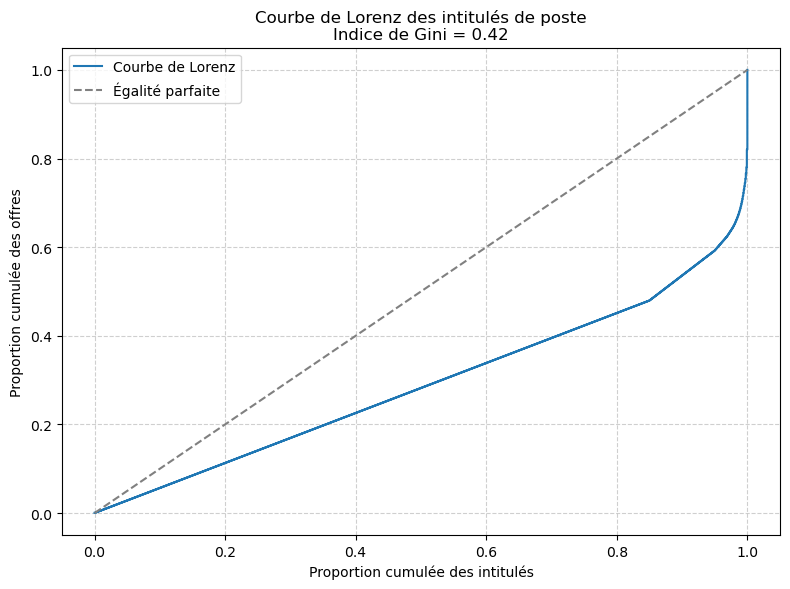

In [20]:
from numpy import cumsum, linspace
from matplotlib import pyplot as plt

# Calcul des fréquences d'intitulés
titleCounts = data['Job Title'].value_counts()
titleCountsSorted = titleCounts.sort_values()

# Courbe de Lorenz
cumCounts = cumsum(titleCountsSorted)
cumProp = cumCounts / cumCounts.iloc[-1]  # normalisation
propTitles = linspace(0, 1, len(cumProp))  # proportions cumulées des intitulés

# Indice de Gini
B = cumProp.sum() / len(cumProp)
giniIndex = 1 - 2 * B

# Tracé
plt.figure(figsize=(8, 6))
plt.plot(propTitles, cumProp, drawstyle='steps-post', label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Égalité parfaite')
plt.title(f"Courbe de Lorenz des intitulés de poste\nIndice de Gini = {giniIndex:.2f}")
plt.xlabel("Proportion cumulée des intitulés")
plt.ylabel("Proportion cumulée des offres")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Le barplot des intitulés de poste montre une forte concentration des offres autour du titre « Data Analyst », largement dominant par rapport aux autres. Ce constat est renforcé par la courbe de Lorenz, qui met en évidence une inégalité marquée dans la répartition des intitulés.

L’indice de Gini associé à cette courbe confirme cette concentration, avec une valeur de 0.91, ce qui est très élevé. Cela signifie que la majorité des offres d’emploi se concentrent sur un très petit nombre d’intitulés, ce qui peut traduire une certaine standardisation du métier.

### Relation entre nombre d'offres et salaire moyen

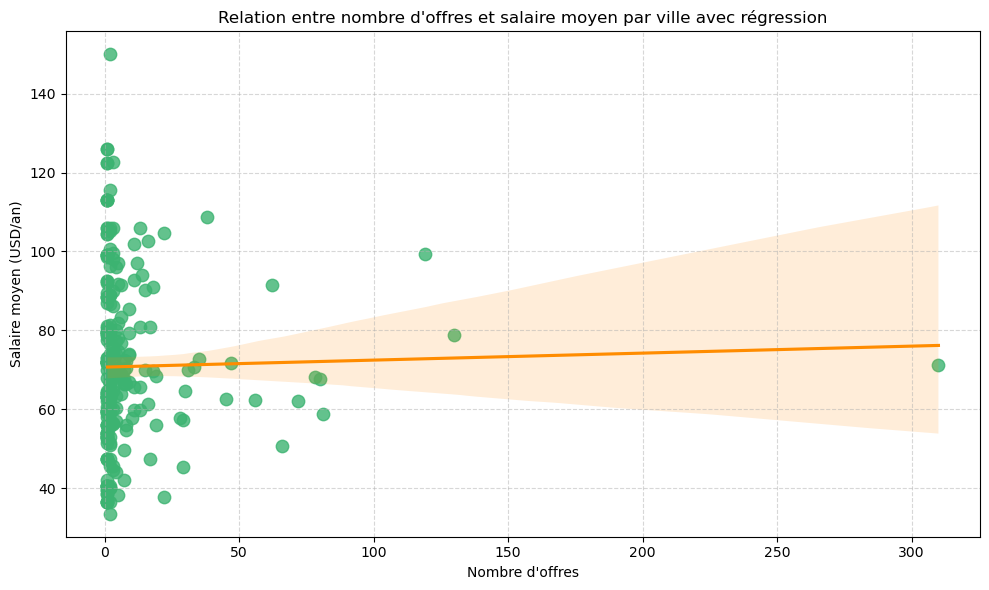

In [63]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=salaryByCity,
    x='offerCount',
    y='avgSalary',
    scatter_kws={'s': 80, 'color': 'mediumseagreen'},
    line_kws={'color': 'darkorange'}
)

plt.title("Relation entre nombre d'offres et salaire moyen par ville avec régression")
plt.xlabel("Nombre d'offres")
plt.ylabel("Salaire moyen (USD/an)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Boxplot nombre d'offres par villes

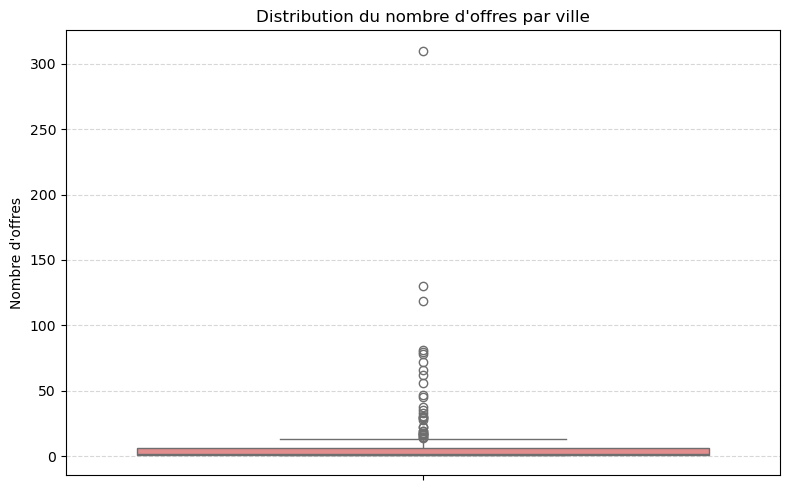

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=salaryByCity['offerCount'], color='lightcoral')
plt.title("Distribution du nombre d'offres par ville")
plt.ylabel("Nombre d'offres")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

    Le boxplot ci-dessus met en évidence une forte concentration des villes autour de faibles volumes d’offres, avec plusieurs valeurs atypiques, dont New York, qui se distingue nettement des autres.

    Même si New York apparaît clairement comme un outlier statistique, j’ai choisi de ne pas l’exclure de l’analyse précédente pour ne pas induire de biai. En effet, le retirer aurait pu gommer une réalité du marché : certaines villes, comme New York, concentrent naturellement beaucoup plus d’opportunités, et cela fait pleinement partie des dynamiques observables dans le secteur de la data.

## 5. Interprétations et insights métiers

Dans cette partie, je propose une synthèse des observations précédentes, avec une mise en perspective du marché de l’emploi dans le domaine de la data analyse. L’objectif est d’identifier les tendances les plus marquantes, mais aussi leurs limites, afin de mieux comprendre les dynamiques actuelles du métier de Data Analyst.

1. Le volume d’offres est significatif
Avec plus de 2 200 offres d’emploi analysées, le dataset met en évidence une demande importante en Data Analysts à l’échelle internationale. Ce volume seul justifie déjà l’intérêt d’une orientation vers ce métier, mais mériterait d’être comparé à d'autres secteurs pour mieux évaluer la place relative de la data.

2. Les salaires sont globalement attractifs
Le salaire moyen est d’environ 72 120 USD/an, et le salaire médian de 69 000 USD/an.
L’écart relativement modéré entre les deux indique une distribution assez équilibrée, bien que la présence de salaires très élevés tire la moyenne vers le haut (skewness = 0.91). Cela montre que le métier est à la fois accessible et potentiellement très bien rémunéré.

3. Des écarts de rémunération selon les villes, mais à interpréter avec prudence
Certaines villes proposent des salaires très élevés, mais ces moyennes sont parfois basées sur seulement une ou deux offres, ce qui limite leur fiabilité. À l’inverse, d’autres villes regroupent un grand nombre d’offres avec des salaires plus standards. New York, par exemple, est un outlier, mais sa dominance est statistiquement justifiée par son poids économique.

4. Une forte concentration des intitulés de poste
Le poste de "Data Analyst" représente à lui seul la majorité des intitulés. L’analyse de la courbe de Lorenz et l’indice de Gini (0.91) montrent une concentration très marquée, confirmant que ce métier est bien identifié et recherché. Cela renforce l’intérêt de viser cet intitulé précis lors d’une recherche d’emploi ou d’une reconversion.

5. Une concentration géographique forte, portée par les grands pôles économiques
Les offres sont massivement concentrées dans des villes comme New York, Chicago ou San Francisco, ce qui reflète l’attractivité des hubs technologiques ou financiers. Cela peut représenter un levier de mobilité professionnelle, mais souligne aussi l’importance d’adapter sa recherche aux dynamiques locales.

## 6. Conclusion sur le marché de la data analyse

Cette analyse confirme que le métier de Data Analyst s’inscrit dans une **dynamique forte du marché de l’emploi**, avec un volume conséquent d’offres, des salaires globalement attractifs et une standardisation des intitulés qui facilite l'identification des opportunités.

Les données étudiées mettent également en lumière des **disparités géographiques**, des **écarts de rémunération**, et une **concentration autour de certains pôles économiques**, notamment aux États-Unis. Ces éléments suggèrent que le marché est à la fois **structuré, évolutif, et sélectif**, avec des opportunités réelles mais localisées.

Dans une perspective de reconversion professionnelle, le métier de Data Analyst présente plusieurs avantages :
- Il est **clairement identifié par les employeurs**
- Il offre une **portabilité internationale**
- Il est **accessible à différents niveaux d’expérience**
- Il correspond à des besoins durables liés à la transformation numérique des entreprises

L’ensemble de ces éléments justifie pleinement un choix de réorientation vers ce domaine, avec des perspectives solides à court et moyen terme, en France comme à l’étranger.